In [1]:
# add_cna_signal.ipynb - add CNA signals to adata count data.

In [2]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sccnasim.xlib.xrange import format_chrom

# Load count matrix as adata

In [3]:
sample_prefix = 'HCC3N_simu.gene.countmatrix.scDesign2Simulated'

work_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/scdesign2_screadsim/simu/matrix"
in_matrix_fn = os.path.join(work_dir, '%s.txt' % sample_prefix)
in_cell_anno_fn = os.path.join(work_dir, '%s.CellTypeLabel.txt' % sample_prefix)
out_raw_adata_fn = os.path.join(work_dir, '%s.raw.h5ad' % sample_prefix)
out_cna_adata_fn = os.path.join(work_dir, '%s.cna.h5ad' % sample_prefix)

cna_profile_fn = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/data/cna_profile.tsv"

In [4]:
gene_anno = pd.read_csv(in_matrix_fn, header = None, delimiter = '\t', usecols = [0])
gene_anno.columns = ['gene']
gene_anno

,gene
0,1_29554_31109
1,1_34554_36081
2,1_65419_71585
3,1_89295_133723
4,1_139790_140339
...,...
21204,9_137554904_137578935
21205,9_137582079_137590490
21206,9_137605654_137618906
21207,9_137618963_138124624


In [5]:
gene_anno[['chrom', 'start', 'end']] = gene_anno['gene'].str.split('_', expand = True)
gene_anno['start'] = gene_anno['start'].astype(int)
gene_anno['end'] = gene_anno['end'].astype(int)
gene_anno

,gene,chrom,start,end
0,1_29554_31109,1,29554,31109
1,1_34554_36081,1,34554,36081
2,1_65419_71585,1,65419,71585
3,1_89295_133723,1,89295,133723
4,1_139790_140339,1,139790,140339
...,...,...,...,...
21204,9_137554904_137578935,9,137554904,137578935
21205,9_137582079_137590490,9,137582079,137590490
21206,9_137605654_137618906,9,137605654,137618906
21207,9_137618963_138124624,9,137618963,138124624


In [6]:
cell_anno = pd.read_csv(in_cell_anno_fn, header = None, delimiter = '\t', usecols = [0])
cell_anno.columns = ['cell_type']
cell_anno

,cell_type
0,normal
1,normal
2,normal
3,normal
4,normal
...,...
1195,normal
1196,normal
1197,normal
1198,normal


In [7]:
np.random.seed(1)
idx = np.random.choice(range(1200), size = 600, replace = False)
idx[:10]

array([ 636,  683, 1033,  190, 1083,  283,  817,  314,  537,  664])

In [8]:
cell_anno.loc[idx, 'cell_type'] = 'tumor'
cell_anno['cell_type'].value_counts()

cell_type
tumor     600
normal    600
Name: count, dtype: int64

In [9]:
data = np.genfromtxt(in_matrix_fn, delimiter = '\t', usecols = range(1, 1201))
data.shape

(21209, 1200)

In [10]:
adata = ad.AnnData(
    X = data.T,
    obs = cell_anno,
    var = gene_anno
)
adata

/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 1200 × 21209
    obs: 'cell_type'
    var: 'gene', 'chrom', 'start', 'end'

In [11]:
target_chroms = [str(i) for i in range(1, 23)]
adata = adata[:, adata.var['chrom'].isin(target_chroms)].copy()
adata

AnnData object with n_obs × n_vars = 1200 × 21209
    obs: 'cell_type'
    var: 'gene', 'chrom', 'start', 'end'

In [12]:
adata.write_h5ad(out_raw_adata_fn)

# Add CNA signals

In [13]:
in_adata_fn = out_raw_adata_fn
out_dir = work_dir
out_adata_fn = out_cna_adata_fn

## Load data

In [14]:
adata = ad.read_h5ad(in_adata_fn)
adata

AnnData object with n_obs × n_vars = 1200 × 21209
    obs: 'cell_type'
    var: 'gene', 'chrom', 'start', 'end'

In [15]:
adata.X = adata.X.astype('float32')

In [16]:
adata.var['chrom'] = adata.var['chrom'].astype(str)
adata.var

,gene,chrom,start,end
0,1_29554_31109,1,29554,31109
1,1_34554_36081,1,34554,36081
2,1_65419_71585,1,65419,71585
3,1_89295_133723,1,89295,133723
4,1_139790_140339,1,139790,140339
...,...,...,...,...
21204,9_137554904_137578935,9,137554904,137578935
21205,9_137582079_137590490,9,137582079,137590490
21206,9_137605654_137618906,9,137605654,137618906
21207,9_137618963_138124624,9,137618963,138124624


In [17]:
cna_profile = pd.read_csv(cna_profile_fn, sep = '\t', header = None, dtype = {0:str})
cna_profile.columns = ['chrom', 'start', 'end', 'clone', 'cn0', 'cn1']
cna_profile

,chrom,start,end,clone,cn0,cn1
0,chr1,123400001,248956422,tumor,1,2
1,chr4,50000001,190214555,tumor,0,1
2,chr8,1,45200000,tumor,0,1
3,chr8,45200001,145138636,tumor,1,2
4,chr13,17700001,114364328,tumor,2,0
5,chr17,1,25100000,tumor,2,0


In [18]:
cna_profile['region'] = cna_profile['chrom'] + ':' + cna_profile['start'].map(str) + '-' + cna_profile['end'].map(str)
cna_profile

cna_profile['cna_type'] = 'N.A.'
cna_profile.loc[cna_profile['cn0'] + cna_profile['cn1'] > 2, 'cna_type'] = 'gain'
cna_profile.loc[cna_profile['cn0'] + cna_profile['cn1'] < 2, 'cna_type'] = 'loss'
cna_profile.loc[cna_profile['cn0'] + cna_profile['cn1'] == 2, 'cna_type'] = 'loh'
cna_profile

,chrom,start,end,clone,cn0,cn1,region,cna_type
0,chr1,123400001,248956422,tumor,1,2,chr1:123400001-248956422,gain
1,chr4,50000001,190214555,tumor,0,1,chr4:50000001-190214555,loss
2,chr8,1,45200000,tumor,0,1,chr8:1-45200000,loss
3,chr8,45200001,145138636,tumor,1,2,chr8:45200001-145138636,gain
4,chr13,17700001,114364328,tumor,2,0,chr13:17700001-114364328,loh
5,chr17,1,25100000,tumor,2,0,chr17:1-25100000,loh


## Find CNA genes

In [19]:
def get_overlap_genes(df, anno):
    df["chrom"] = df["chrom"].map(format_chrom)
    anno["chrom"] = anno["chrom"].map(format_chrom)

    df = df.drop_duplicates("region", ignore_index = True)
    anno = anno.drop_duplicates("gene", ignore_index = True)

    overlap = df.groupby("region").apply(
        lambda x: anno.loc[
            (anno["chrom"] == x["chrom"].values[0]) &
            (anno["start"] <= x["end"].values[0]) &
            (anno["end"] >= x["start"].values[0])
        ]).reset_index()
    
    if 'level_1' in overlap.columns:
        overlap.drop(columns = ['level_1'], inplace = True)
    overlap = overlap.merge(df[['region', 'cn0', 'cn1', 'cna_type']], on = 'region', how = 'left')

    stat = overlap.groupby("gene").size().reset_index(name = "n_overlap_region")
    dup = stat[stat["n_overlap_region"] > 1]
    uniq = stat[stat["n_overlap_region"] == 1].merge(overlap, on = "gene", how = "left")
    uniq = uniq.sort_values(by = ["region", 'chrom', 'start', 'end', 'gene'])

    res = dict(
        # overlap : pandas.DataFrame
        #   The overlapping results. It contains two columns:
        #   - "region": region ID.
        #   - "gene": name of genes overlapping the region.
        overlap = overlap,

        # n_region : int
        #   Number of unique regions.
        n_region = df.shape[0],

        # n_region_overlap : int
        #   Number of unique regions that have overlapping genes.
        n_region_overlap = len(overlap["region"].unique()),

        # n_gene : int
        #   Number of unique genes.
        n_gene = anno.shape[0],

        # n_gene_overlap : int
        #   Number of unique genes that have overlapping regions.
        n_gene_overlap = len(overlap["gene"].unique()),

        # n_gene_dup : int
        #   Number of genes overlapping more than 1 regions.
        n_gene_dup = dup.shape[0],

        # overlap_uniq : pandas.DataFrame
        #   The overlapping results.
        #   Similar to `overlap`, but the genes overlapping more than 1 regions
        #   are removed.
        overlap_uniq = uniq
    )

    return(res)

In [20]:
res = get_overlap_genes(df = cna_profile, anno = adata.var.copy())

/tmp/pbs.1793496.xomics/ipykernel_17156/1258343097.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overlap = df.groupby("region").apply(


In [21]:
res.keys()

dict_keys(['overlap', 'n_region', 'n_region_overlap', 'n_gene', 'n_gene_overlap', 'n_gene_dup', 'overlap_uniq'])

In [22]:
res['overlap']

,region,gene,chrom,start,end,cn0,cn1,cna_type
0,chr13:17700001-114364328,13_18195297_18232024,13,18195297,18232024,2,0,loh
1,chr13:17700001-114364328,13_18540497_18550697,13,18540497,18550697,2,0,loh
2,chr13:17700001-114364328,13_18610298_18611675,13,18610298,18611675,2,0,loh
3,chr13:17700001-114364328,13_18672827_18676163,13,18672827,18676163,2,0,loh
4,chr13:17700001-114364328,13_18905439_18907810,13,18905439,18907810,2,0,loh
...,...,...,...,...,...,...,...,...
3403,chr8:45200001-145138636,8_144876497_144902168,8,144876497,144902168,1,2,gain
3404,chr8:45200001-145138636,8_144930358_144950888,8,144930358,144950888,1,2,gain
3405,chr8:45200001-145138636,8_144992914_144994837,8,144992914,144994837,1,2,gain
3406,chr8:45200001-145138636,8_145002811_145006046,8,145002811,145006046,1,2,gain


In [23]:
res['overlap_uniq']

,gene,n_overlap_region,region,chrom,start,end,cn0,cn1,cna_type
92,13_18195297_18232024,1,chr13:17700001-114364328,13,18195297,18232024,2,0,loh
93,13_18540497_18550697,1,chr13:17700001-114364328,13,18540497,18550697,2,0,loh
94,13_18610298_18611675,1,chr13:17700001-114364328,13,18610298,18611675,2,0,loh
95,13_18672827_18676163,1,chr13:17700001-114364328,13,18672827,18676163,2,0,loh
96,13_18905439_18907810,1,chr13:17700001-114364328,13,18905439,18907810,2,0,loh
...,...,...,...,...,...,...,...,...,...
2848,8_144876497_144902168,1,chr8:45200001-145138636,8,144876497,144902168,1,2,gain
2849,8_144930358_144950888,1,chr8:45200001-145138636,8,144930358,144950888,1,2,gain
2850,8_144992914_144994837,1,chr8:45200001-145138636,8,144992914,144994837,1,2,gain
2851,8_145002811_145006046,1,chr8:45200001-145138636,8,145002811,145006046,1,2,gain


In [24]:
res['overlap'].loc[~(res['overlap']['gene'].isin(res['overlap_uniq']['gene']))]

,region,gene,chrom,start,end,cn0,cn1,cna_type


In [25]:
res['overlap_uniq']['cna_type'].value_counts()

cna_type
gain    1608
loss    1004
loh      796
Name: count, dtype: int64

In [26]:
res['overlap'].to_csv(
    os.path.join(out_dir, 'cna_genes.tsv'),
    sep = '\t',
    index = False
)

In [27]:
res['overlap_uniq'].to_csv(
    os.path.join(out_dir, 'cna_genes.unique.tsv'),
    sep = '\t',
    index = False
)

### Update adata, masking multi-overlap features

In [28]:
mof = res['overlap'].loc[~(res['overlap']['gene'].isin(res['overlap_uniq']['gene'])), 'gene'].to_numpy()
mof

array([], dtype=object)

In [29]:
adata.X[:, adata.var['gene'].isin(mof)] = 0

## Add copy gain signals

In [30]:
df = res['overlap_uniq']
cna_genes = df.loc[df['cna_type'] == 'gain', 'gene'].to_numpy()
print(cna_genes.shape)
cna_genes[:10]

(1608,)


array(['1_143499187_143500512', '1_143736066_143739506',
       '1_143790010_143797108', '1_143877731_143885076',
       '1_143905487_143934776', '1_143955364_143971965',
       '1_144085628_144086098', '1_144227030_144250288',
       '1_144372875_144373659', '1_144418113_144419192'], dtype=object)

In [31]:
idx = np.ix_(adata.obs['cell_type'] == 'tumor', adata.var['gene'].isin(cna_genes))
print(adata.X[idx].shape)
adata.X[idx] = adata.X[idx] * 1.5
X_tumor = adata.X[idx]

(600, 1608)


In [32]:
idx = np.ix_(adata.obs['cell_type'] == 'normal', adata.var['gene'].isin(cna_genes))
X_normal = adata.X[idx]

In [33]:
fc = ( X_tumor.mean(axis = 0)*1e6 ) / ( X_normal.mean(axis = 0)*1e6 + 1e-8 )
fc[fc > 4] = 4
RD = np.log10(X_normal.mean(axis = 0) + 1)

Text(0, 0.5, 'Gene Fold Change (tumor vs. normal)')

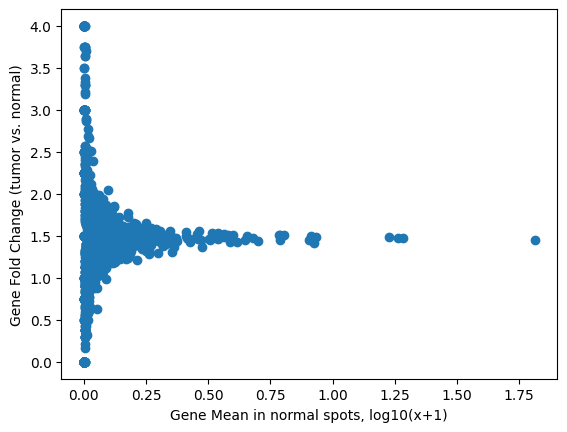

In [34]:
plt.scatter(RD, fc)
plt.xlabel('Gene Mean in normal spots, log10(x+1)')
plt.ylabel('Gene Fold Change (tumor vs. normal)')

## Add copy loss signals

In [35]:
df = res['overlap_uniq']
cna_genes = df.loc[df['cna_type'] == 'loss', 'gene'].to_numpy()
print(cna_genes.shape)
cna_genes[:10]

(1004,)


array(['4_51843000_51916837', '4_51918772_51919381',
       '4_51993702_52017620', '4_52020706_52038482',
       '4_52044805_52046954', '4_52051331_52097292',
       '4_52590972_52659335', '4_52659406_52661668',
       '4_52680609_52692649', '4_52722618_52751640'], dtype=object)

In [36]:
idx = np.ix_(adata.obs['cell_type'] == 'tumor', adata.var['gene'].isin(cna_genes))
print(adata.X[idx].shape)
adata.X[idx] = adata.X[idx] * 0.5
X_tumor = adata.X[idx]

(600, 1004)


In [37]:
idx = np.ix_(adata.obs['cell_type'] == 'normal', adata.var['gene'].isin(cna_genes))
X_normal = adata.X[idx]

In [38]:
fc = ( X_tumor.mean(axis = 0)*1e6 ) / ( X_normal.mean(axis = 0)*1e6 + 1e-8 )
fc[fc > 4] = 4
RD = np.log10(X_normal.mean(axis = 0) + 1)

Text(0, 0.5, 'Gene Fold Change (tumor vs. normal)')

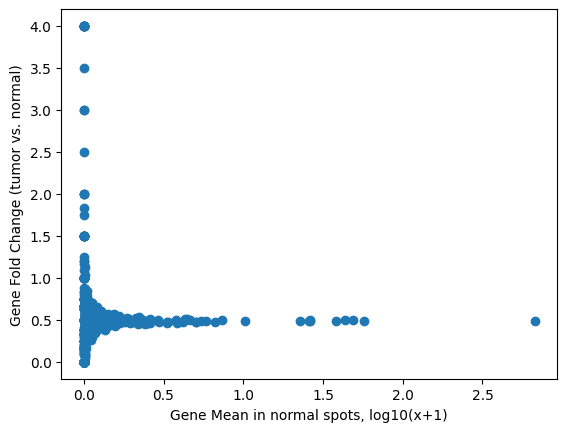

In [39]:
plt.scatter(RD, fc)
plt.xlabel('Gene Mean in normal spots, log10(x+1)')
plt.ylabel('Gene Fold Change (tumor vs. normal)')

## Save adata

In [40]:
adata.var

,gene,chrom,start,end
0,1_29554_31109,1,29554,31109
1,1_34554_36081,1,34554,36081
2,1_65419_71585,1,65419,71585
3,1_89295_133723,1,89295,133723
4,1_139790_140339,1,139790,140339
...,...,...,...,...
21204,9_137554904_137578935,9,137554904,137578935
21205,9_137582079_137590490,9,137582079,137590490
21206,9_137605654_137618906,9,137605654,137618906
21207,9_137618963_138124624,9,137618963,138124624


In [41]:
adata.var = adata.var.merge(res['overlap_uniq'][["gene", "region", "cn0", "cn1", "cna_type"]], on = "gene", how = "left")
adata.var

,gene,chrom,start,end,region,cn0,cn1,cna_type
0,1_29554_31109,1,29554,31109,NaN,NaN,NaN,NaN
1,1_34554_36081,1,34554,36081,NaN,NaN,NaN,NaN
2,1_65419_71585,1,65419,71585,NaN,NaN,NaN,NaN
3,1_89295_133723,1,89295,133723,NaN,NaN,NaN,NaN
4,1_139790_140339,1,139790,140339,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
21204,9_137554904_137578935,9,137554904,137578935,NaN,NaN,NaN,NaN
21205,9_137582079_137590490,9,137582079,137590490,NaN,NaN,NaN,NaN
21206,9_137605654_137618906,9,137605654,137618906,NaN,NaN,NaN,NaN
21207,9_137618963_138124624,9,137618963,138124624,NaN,NaN,NaN,NaN


In [42]:
adata.var['cna_type'].value_counts()

cna_type
gain    1608
loss    1004
loh      796
Name: count, dtype: int64

In [43]:
adata.write(out_adata_fn, compression = 'gzip')

### Save to scReadSim count matrix format file

In [44]:
df = pd.DataFrame(adata.X.T)
df.index = adata.var['gene']
df

,0,1,2,3,4,5,6,7,8,9,...,1190,1191,1192,1193,1194,1195,1196,1197,1198,1199
gene,,,,,,,,,,,,,,,,,,,,,
1_29554_31109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1_34554_36081,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1_65419_71585,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1_89295_133723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1_139790_140339,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9_137554904_137578935,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9_137582079_137590490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9_137605654_137618906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
fn = os.path.join(out_dir, '%s.cna.txt' % sample_prefix)
df.to_csv(fn, sep = '\t', header = False, index = True)

In [46]:
fn = os.path.join(out_dir, '%s.cna.CellTypeLabel.txt' % sample_prefix)
adata.obs[['cell_type']].to_csv(fn, sep = '\t', header = False, index = False)